# 📊 Task 4: Data Visualization
## Comprehensive EDA & Visual Analytics using Matplotlib and Seaborn

---

**Dataset:** Titanic Passenger Survival Dataset  
**Source:** [Seaborn Built-in / OpenML](https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv)  
**Objective:** Perform end-to-end data visualization to extract meaningful insights from the Titanic dataset using Matplotlib and Seaborn.

---

### 📌 Table of Contents
1. Environment Setup & Imports
2. Data Loading & Overview
3. Univariate Analysis
4. Bivariate Analysis
5. Multivariate Analysis
6. Correlation Heatmap
7. Advanced Visualizations
8. Summary of Insights

---

## 1. 🔧 Environment Setup & Imports

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
#  INSTALL DEPENDENCIES  (only needed in fresh Colab environments)
# ─────────────────────────────────────────────────────────────────────────────
# !pip install matplotlib seaborn pandas numpy --quiet

# ─────────────────────────────────────────────────────────────────────────────
#  STANDARD IMPORTS
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────────────────────────
#  GLOBAL STYLE SETTINGS
# ─────────────────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='deep', font_scale=1.15)
plt.rcParams.update({
    'figure.dpi'       : 120,
    'figure.facecolor' : 'white',
    'axes.facecolor'   : '#f9f9f9',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.family'      : 'DejaVu Sans',
})

# Colour palettes used throughout
PALETTE_SURVIVAL = {0: '#E74C3C', 1: '#2ECC71'}   # red = died, green = survived
PALETTE_CLASS    = ['#3498DB', '#F39C12', '#9B59B6']
PALETTE_GENDER   = {'male': '#3498DB', 'female': '#E91E63'}

print('✅  All libraries loaded successfully.')
print(f'   pandas  : {pd.__version__}')
print(f'   numpy   : {np.__version__}')
print(f'   seaborn : {sns.__version__}')
print(f'   matplotlib : {plt.matplotlib.__version__}')

✅  All libraries loaded successfully.
   pandas  : 2.2.2
   numpy   : 2.0.2
   seaborn : 0.13.2
   matplotlib : 3.10.0


## 2. 📥 Data Loading & Overview

**Dataset URL:**  
```
https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv
```

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
#  LOAD DATASET
# ─────────────────────────────────────────────────────────────────────────────
URL = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'

df = pd.read_csv(URL)
print(f'Dataset shape : {df.shape[0]} rows × {df.shape[1]} columns\n')

# ── Column rename for clarity ───────────────────────────────────────────────
df.rename(columns={
    'Survived': 'Survived',
    'Pclass'  : 'PClass',
    'SibSp'   : 'SiblingSpouse',
    'Parch'   : 'ParentChild',
}, inplace=True)

# ── Basic feature engineering for visualisation ─────────────────────────────
df['FamilySize']   = df['SiblingSpouse'] + df['ParentChild'] + 1
df['IsAlone']      = (df['FamilySize'] == 1).astype(int)
df['AgeGroup']     = pd.cut(df['Age'],
                            bins=[0, 12, 18, 35, 60, 120],
                            labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])
df['FareGroup']    = pd.qcut(df['Fare'], q=4,
                             labels=['Low', 'Medium', 'High', 'Very High'])
df['Survived_Label'] = df['Survived'].map({0: 'Did Not Survive', 1: 'Survived'})
df['Sex_Label']      = df['Sex'].str.capitalize()

print(df.head())

Dataset shape : 891 rows × 12 columns

   PassengerId  Survived  PClass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  \
0                            Braund, Mr. Owen Harris    male  22.0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0   
2                             Heikkinen, Miss. Laina  female  26.0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0   
4                           Allen, Mr. William Henry    male  35.0   

   SiblingSpouse  ParentChild            Ticket     Fare Cabin Embarked  \
0              1            0         A/5 21171   7.2500   NaN        S   
1              1            0          PC 17599  71.2833   C85        C   
2              0            0  STON/O2. 3101282   7.9250   NaN        S   
3              1       

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
#  DATA OVERVIEW
# ─────────────────────────────────────────────────────────────────────────────
print('=' * 60)
print('  DATASET INFORMATION')
print('=' * 60)
df.info()

print('\n' + '=' * 60)
print('  DESCRIPTIVE STATISTICS')
print('=' * 60)
display(df.describe(include='all').round(2))

print('\n' + '=' * 60)
print('  MISSING VALUES')
print('=' * 60)
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
display(missing_df[missing_df['Missing Count'] > 0])

  DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   PassengerId     891 non-null    int64   
 1   Survived        891 non-null    int64   
 2   PClass          891 non-null    int64   
 3   Name            891 non-null    object  
 4   Sex             891 non-null    object  
 5   Age             714 non-null    float64 
 6   SiblingSpouse   891 non-null    int64   
 7   ParentChild     891 non-null    int64   
 8   Ticket          891 non-null    object  
 9   Fare            891 non-null    float64 
 10  Cabin           204 non-null    object  
 11  Embarked        889 non-null    object  
 12  FamilySize      891 non-null    int64   
 13  IsAlone         891 non-null    int64   
 14  AgeGroup        714 non-null    category
 15  FareGroup       891 non-null    category
 16  Survived_Label  891 non-null    object  

,PassengerId,Survived,PClass,Name,Sex,Age,SiblingSpouse,ParentChild,Ticket,Fare,Cabin,Embarked,FamilySize,IsAlone,AgeGroup,FareGroup,Survived_Label,Sex_Label
count,891.00,891.00,891.00,891,891,714.00,891.00,891.00,891,891.00,204,889,891.00,891.00,714,891,891,891
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3,NaN,NaN,5,4,2,2
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S,NaN,NaN,Young Adult,Medium,Did Not Survive,Male
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644,NaN,NaN,358,224,549,577
mean,446.00,0.38,2.31,NaN,NaN,29.70,0.52,0.38,NaN,32.20,NaN,NaN,1.90,0.60,NaN,NaN,NaN,NaN
std,257.35,0.49,0.84,NaN,NaN,14.53,1.10,0.81,NaN,49.69,NaN,NaN,1.61,0.49,NaN,NaN,NaN,NaN
min,1.00,0.00,1.00,NaN,NaN,0.42,0.00,0.00,NaN,0.00,NaN,NaN,1.00,0.00,NaN,NaN,NaN,NaN
25%,223.50,0.00,2.00,NaN,NaN,20.12,0.00,0.00,NaN,7.91,NaN,NaN,1.00,0.00,NaN,NaN,NaN,NaN
50%,446.00,0.00,3.00,NaN,NaN,28.00,0.00,0.00,NaN,14.45,NaN,NaN,1.00,1.00,NaN,NaN,NaN,NaN
75%,668.50,1.00,3.00,NaN,NaN,38.00,1.00,0.00,NaN,31.00,NaN,NaN,2.00,1.00,NaN,NaN,NaN,NaN



  MISSING VALUES


,Missing Count,Missing %
Age,177,19.87
Cabin,687,77.10
Embarked,2,0.22
AgeGroup,177,19.87


## 3. 📈 Univariate Analysis
Examining individual features to understand their distributions.

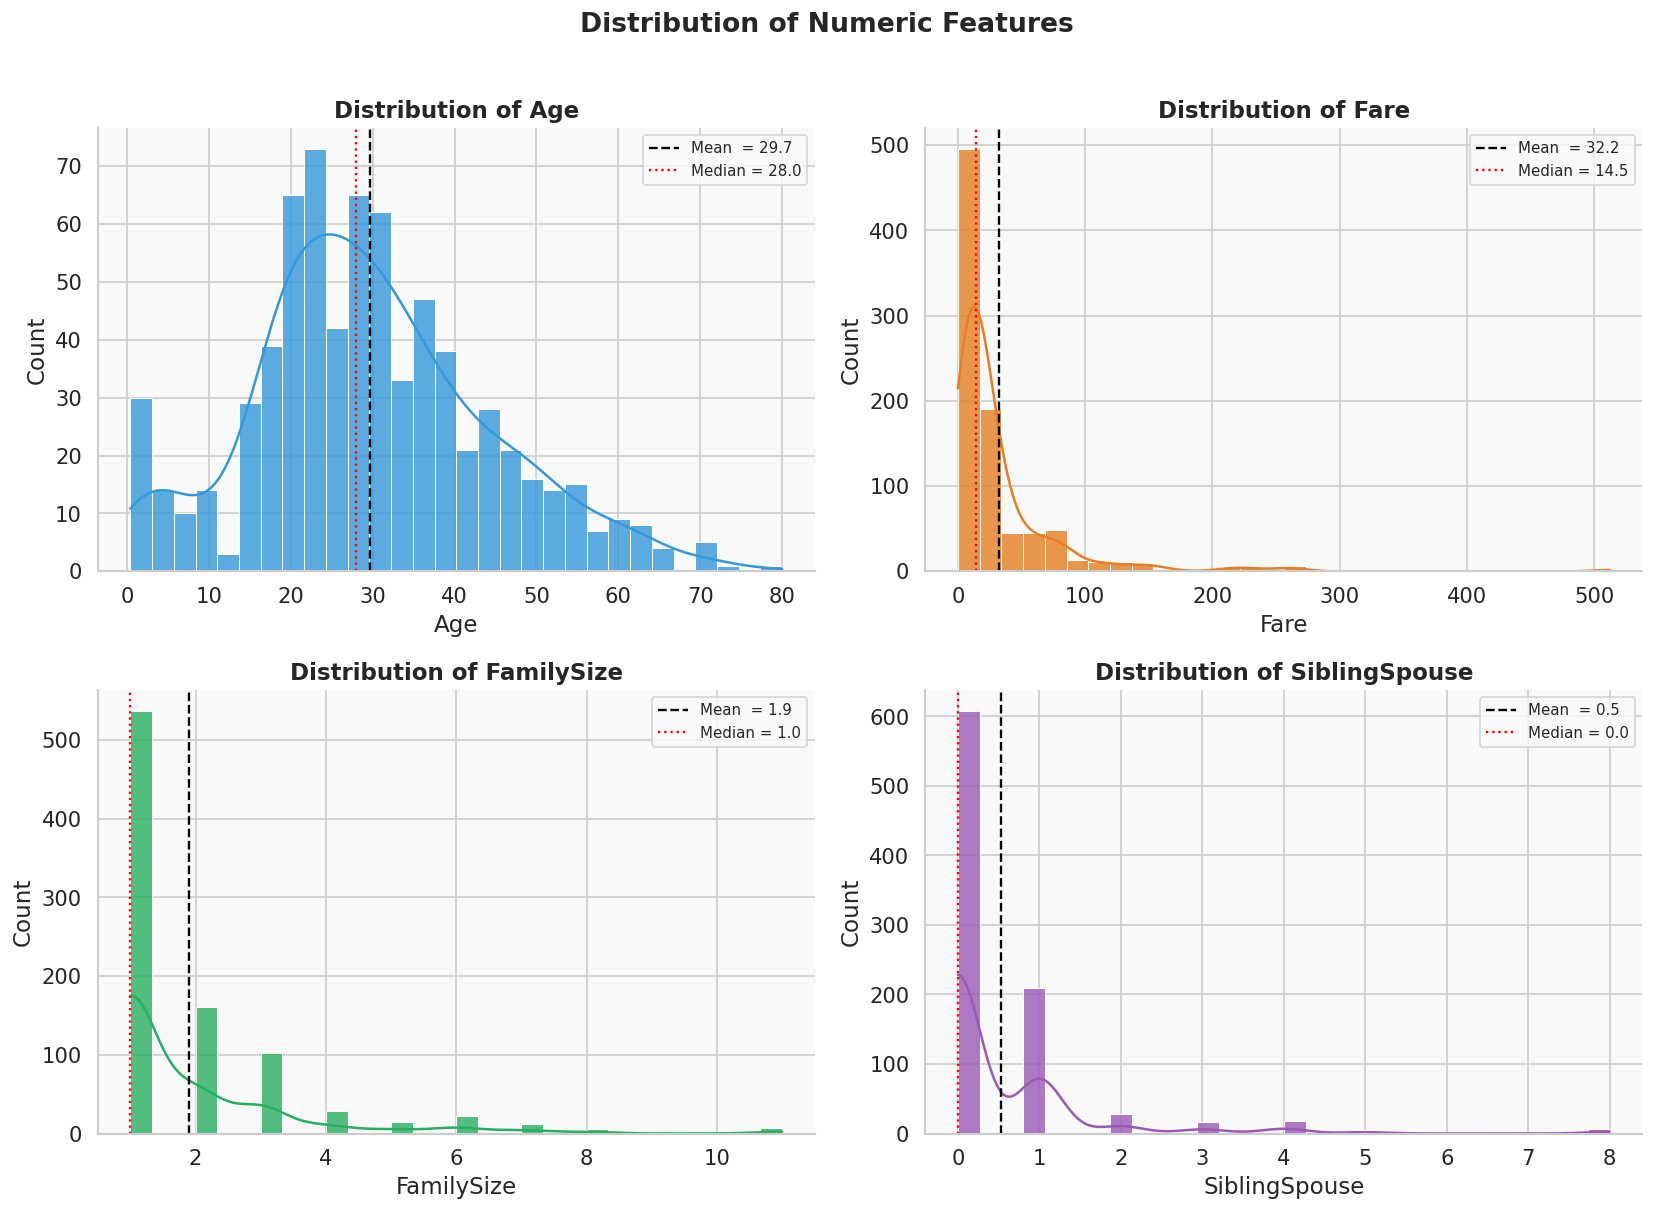

💡 Insight: Age is approximately normally distributed (mean ~30). Fare is right-skewed, indicating most passengers paid low fares with few high-paying outliers.


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
#  FIGURE 1 ─ Distribution of Numeric Features
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution of Numeric Features', fontsize=16, fontweight='bold', y=1.01)

numeric_cols = {'Age': '#3498DB', 'Fare': '#E67E22',
                'FamilySize': '#27AE60', 'SiblingSpouse': '#9B59B6'}

for ax, (col, color) in zip(axes.ravel(), numeric_cols.items()):
    data = df[col].dropna()
    sns.histplot(data, bins=30, color=color, ax=ax, kde=True,
                 edgecolor='white', linewidth=0.6, alpha=0.8)
    ax.axvline(data.mean(),   color='black', linestyle='--', linewidth=1.4,
               label=f'Mean  = {data.mean():.1f}')
    ax.axvline(data.median(), color='red',   linestyle=':',  linewidth=1.4,
               label=f'Median = {data.median():.1f}')
    ax.set_title(f'Distribution of {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig1_univariate_numeric.png', bbox_inches='tight', dpi=150)
plt.show()
print('💡 Insight: Age is approximately normally distributed (mean ~30). Fare is right-skewed,'
      ' indicating most passengers paid low fares with few high-paying outliers.')

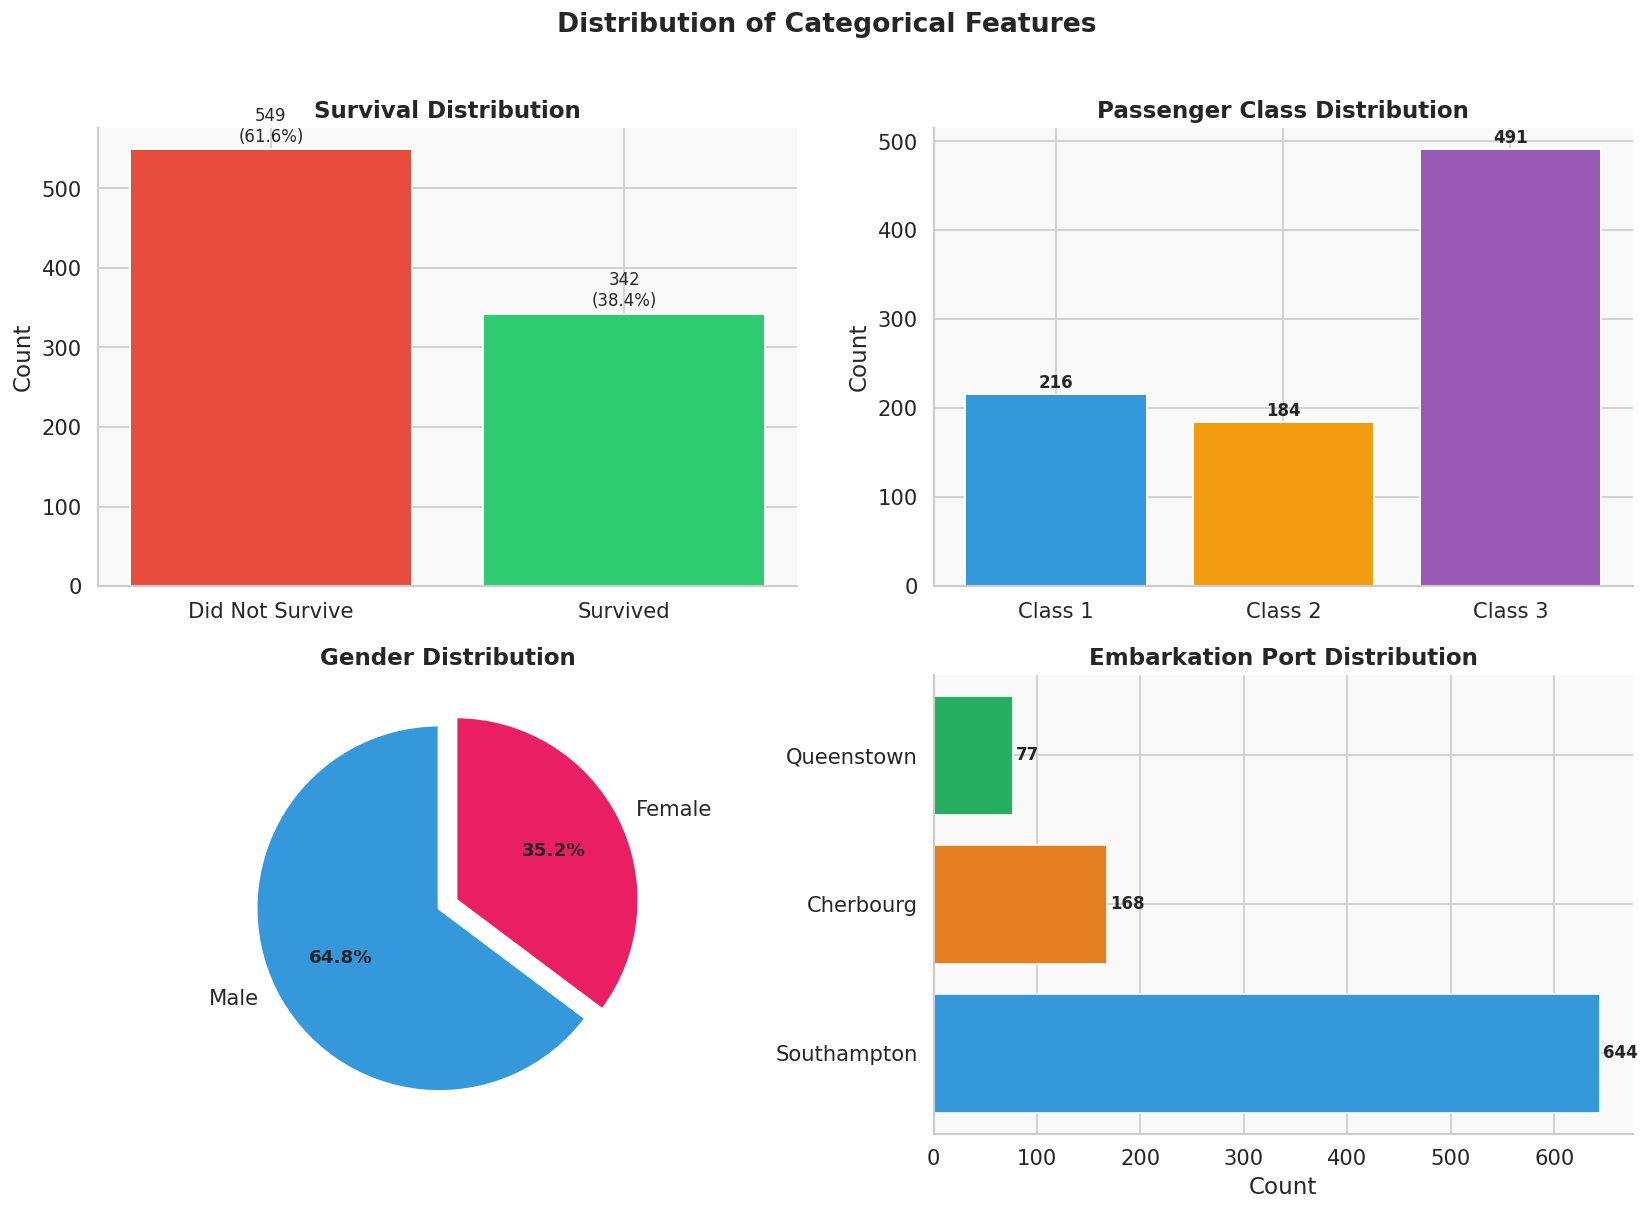

💡 Insight: Only 38% of passengers survived. 3rd class held the most passengers (55%). Male passengers outnumbered females (~65% vs ~35%). Southampton was the primary boarding port.


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
#  FIGURE 2 ─ Distribution of Categorical Features
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution of Categorical Features', fontsize=16, fontweight='bold', y=1.01)

# ── Survival ─────────────────────────────────────────────────────────────────
ax = axes[0, 0]
surv_counts = df['Survived_Label'].value_counts()
bars = ax.bar(surv_counts.index, surv_counts.values,
              color=['#E74C3C', '#2ECC71'], edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, surv_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{val}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=10)
ax.set_title('Survival Distribution', fontweight='bold')
ax.set_ylabel('Count')

# ── Passenger Class ──────────────────────────────────────────────────────────
ax = axes[0, 1]
class_counts = df['PClass'].value_counts().sort_index()
bars = ax.bar([f'Class {c}' for c in class_counts.index], class_counts.values,
              color=PALETTE_CLASS, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            f'{val}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Passenger Class Distribution', fontweight='bold')
ax.set_ylabel('Count')

# ── Gender ───────────────────────────────────────────────────────────────────
ax = axes[1, 0]
sex_counts = df['Sex'].value_counts()
wedges, texts, autotexts = ax.pie(
    sex_counts.values, labels=sex_counts.index.str.capitalize(),
    autopct='%1.1f%%', colors=['#3498DB', '#E91E63'],
    startangle=90, explode=[0.05, 0.05],
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')
ax.set_title('Gender Distribution', fontweight='bold')

# ── Embarkation Port ─────────────────────────────────────────────────────────
ax = axes[1, 1]
emb_map = {'S': 'Southampton', 'C': 'Cherbourg', 'Q': 'Queenstown'}
emb_counts = df['Embarked'].map(emb_map).value_counts()
bars = ax.barh(emb_counts.index, emb_counts.values,
               color=['#3498DB', '#E67E22', '#27AE60'], edgecolor='white')
for bar, val in zip(bars, emb_counts.values):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
            f'{val}', va='center', fontsize=10, fontweight='bold')
ax.set_title('Embarkation Port Distribution', fontweight='bold')
ax.set_xlabel('Count')

plt.tight_layout()
plt.savefig('fig2_univariate_categorical.png', bbox_inches='tight', dpi=150)
plt.show()
print('💡 Insight: Only 38% of passengers survived. 3rd class held the most passengers (55%).',
      'Male passengers outnumbered females (~65% vs ~35%). Southampton was the primary boarding port.')

## 4. 🔍 Bivariate Analysis
Examining relationships between pairs of features.

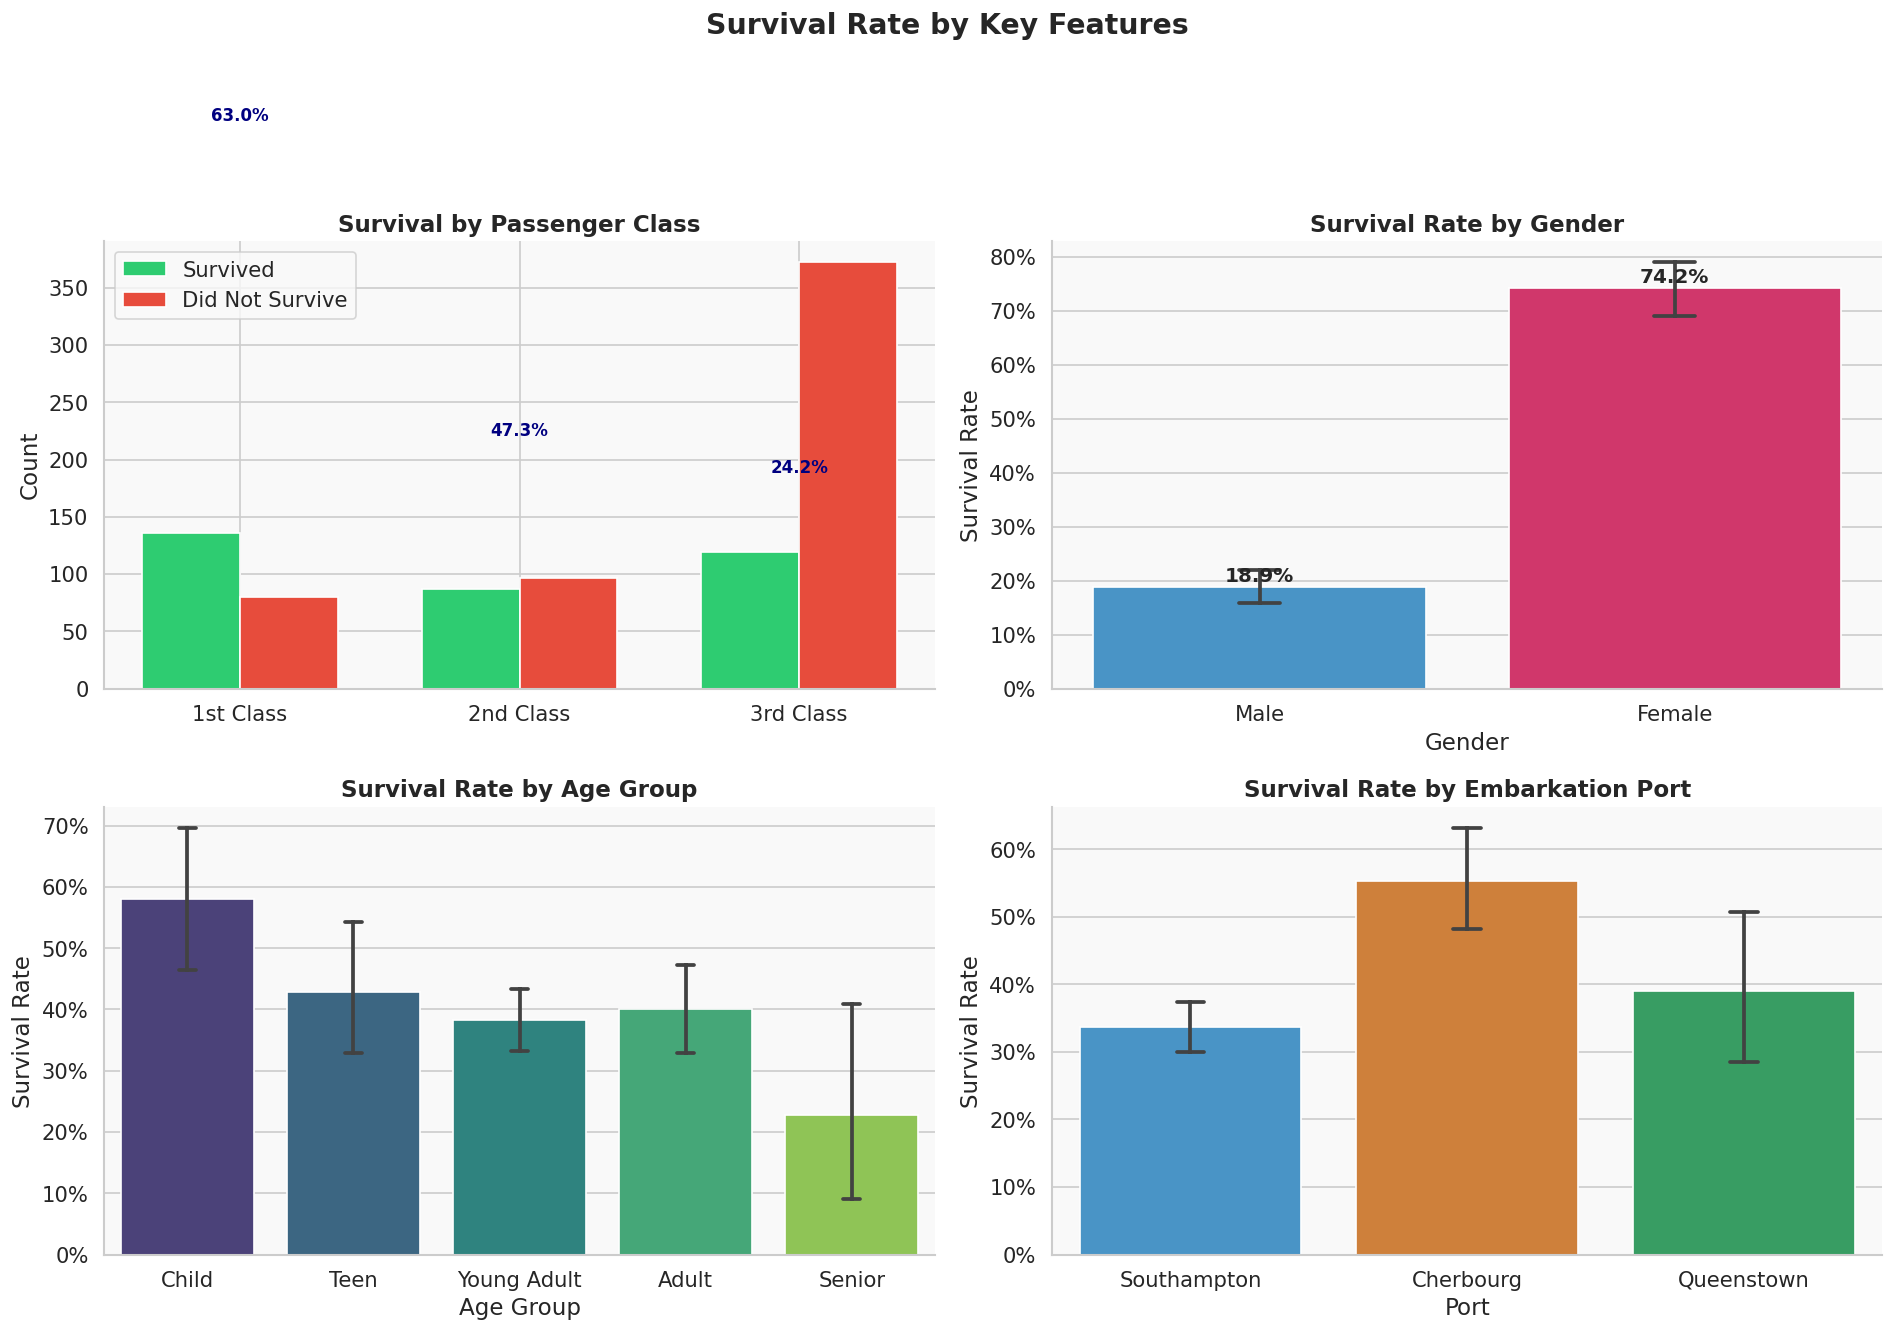

💡 Insight: 1st class passengers had the highest survival rate (~63%). Women survived at ~74% vs men at ~19%. Children had the highest survival rate among age groups.


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
#  FIGURE 3 ─ Survival by Class, Gender, Age Group, and Embarkation
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Survival Rate by Key Features', fontsize=17, fontweight='bold', y=1.01)

# ── 1. Survival by Passenger Class ───────────────────────────────────────────
ax = axes[0, 0]
surv_class = df.groupby('PClass')['Survived'].agg(['sum', 'count'])
surv_class['rate'] = (surv_class['sum'] / surv_class['count'] * 100).round(1)
x = np.arange(len(surv_class))
width = 0.35
b1 = ax.bar(x - width/2, surv_class['sum'],   width, label='Survived', color='#2ECC71', edgecolor='white')
b2 = ax.bar(x + width/2, surv_class['count'] - surv_class['sum'],
            width, label='Did Not Survive', color='#E74C3C', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(['1st Class', '2nd Class', '3rd Class'])
ax.set_title('Survival by Passenger Class', fontweight='bold')
ax.set_ylabel('Count')
ax.legend()
for idx, rate in zip(x, surv_class['rate']):
    ax.text(idx, surv_class.loc[surv_class.index[idx-1], 'count'] + 5,
            f'{rate}%', ha='center', fontsize=10, color='navy', fontweight='bold')

# ── 2. Survival by Gender ─────────────────────────────────────────────────────
ax = axes[0, 1]
sns.barplot(data=df, x='Sex', y='Survived', hue='Sex', palette=PALETTE_GENDER,
            ax=ax, estimator=np.mean, ci=95, capsize=0.1, dodge=False, legend=False)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title('Survival Rate by Gender', fontweight='bold')
ax.set_xlabel('Gender')
ax.set_ylabel('Survival Rate')
ax.set_xticklabels(['Male', 'Female'])
for patch in ax.patches:
    ax.text(patch.get_x() + patch.get_width()/2, patch.get_height() + 0.01,
            f'{patch.get_height()*100:.1f}%', ha='center', fontsize=12, fontweight='bold')

# ── 3. Survival by Age Group ──────────────────────────────────────────────────
ax = axes[1, 0]
age_group_order = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']
sns.barplot(data=df.dropna(subset=['AgeGroup']),
            x='AgeGroup', y='Survived', order=age_group_order,
            palette='viridis', ax=ax, estimator=np.mean, ci=95, capsize=0.1)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title('Survival Rate by Age Group', fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('Survival Rate')

# ── 4. Survival by Embarkation ────────────────────────────────────────────────
ax = axes[1, 1]
emb_surv = df.dropna(subset=['Embarked']).copy()
emb_surv['Port'] = emb_surv['Embarked'].map({'S': 'Southampton', 'C': 'Cherbourg', 'Q': 'Queenstown'})
sns.barplot(data=emb_surv, x='Port', y='Survived',
            palette=['#3498DB', '#E67E22', '#27AE60'], ax=ax,
            estimator=np.mean, ci=95, capsize=0.1)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title('Survival Rate by Embarkation Port', fontweight='bold')
ax.set_xlabel('Port')
ax.set_ylabel('Survival Rate')

plt.tight_layout()
plt.savefig('fig3_bivariate_survival.png', bbox_inches='tight', dpi=150)
plt.show()
print('💡 Insight: 1st class passengers had the highest survival rate (~63%).'
      ' Women survived at ~74% vs men at ~19%. Children had the highest survival rate among age groups.')

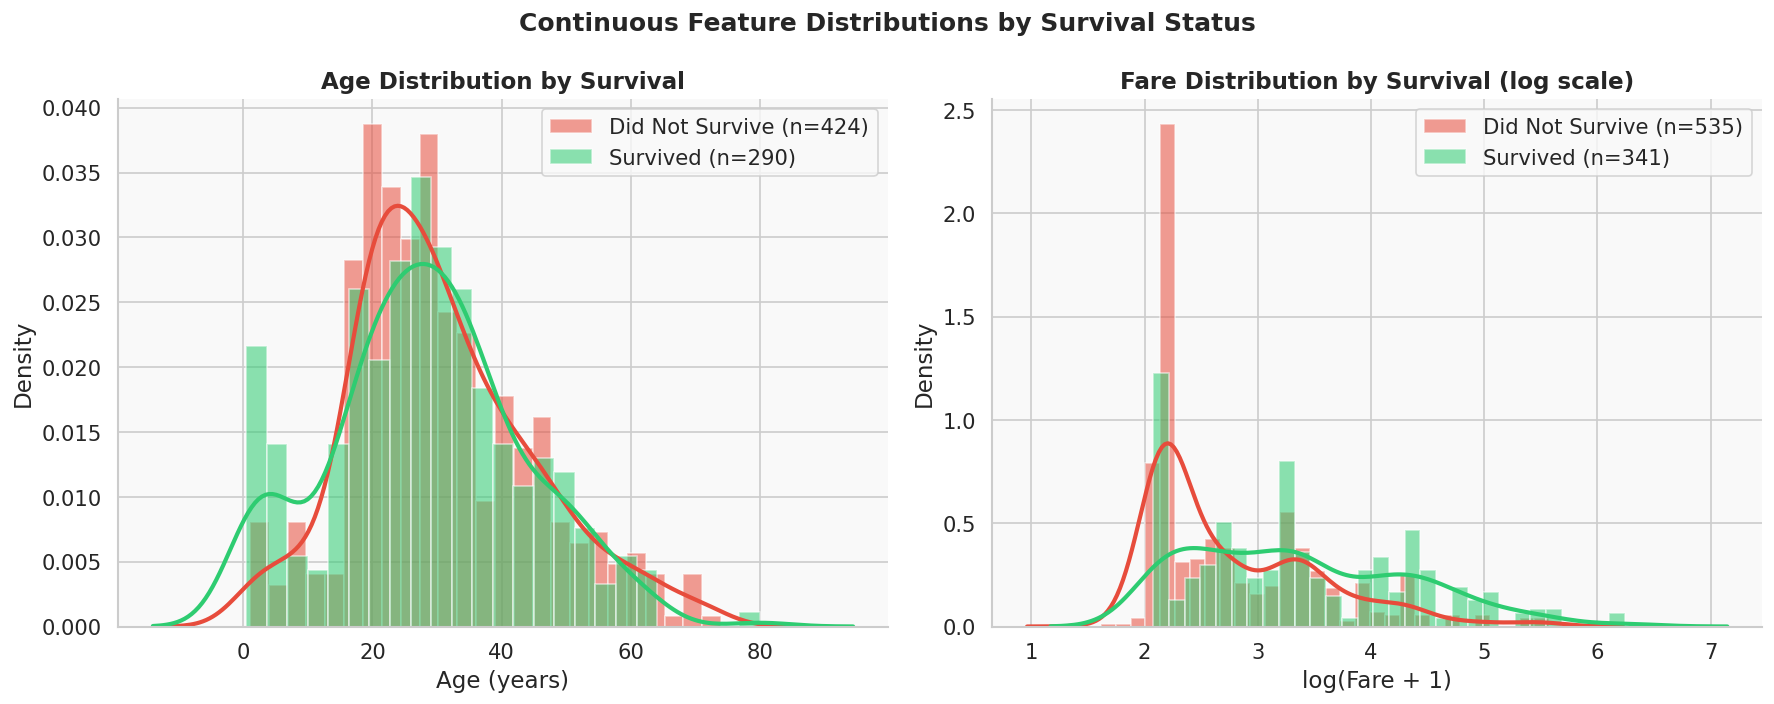

💡 Insight: Survivors paid significantly higher fares on average. Young children show a higher density in the survived group, confirming the earlier finding.


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
#  FIGURE 4 ─ Age & Fare Distributions by Survival
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Continuous Feature Distributions by Survival Status',
             fontsize=15, fontweight='bold')

# ── Age Distribution by Survival ─────────────────────────────────────────────
ax = axes[0]
for survived, color, label in [(0, '#E74C3C', 'Did Not Survive'), (1, '#2ECC71', 'Survived')]:
    subset = df[df['Survived'] == survived]['Age'].dropna()
    ax.hist(subset, bins=25, alpha=0.55, color=color, edgecolor='white',
            label=f'{label} (n={len(subset)})', density=True)
    sns.kdeplot(subset, ax=ax, color=color, linewidth=2.5)
ax.set_title('Age Distribution by Survival', fontweight='bold')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Density')
ax.legend()

# ── Fare Distribution by Survival (log scale) ────────────────────────────────
ax = axes[1]
for survived, color, label in [(0, '#E74C3C', 'Did Not Survive'), (1, '#2ECC71', 'Survived')]:
    subset = df[(df['Survived'] == survived) & (df['Fare'] > 0)]['Fare']
    ax.hist(np.log1p(subset), bins=30, alpha=0.55, color=color, edgecolor='white',
            label=f'{label} (n={len(subset)})', density=True)
    sns.kdeplot(np.log1p(subset), ax=ax, color=color, linewidth=2.5)
ax.set_title('Fare Distribution by Survival (log scale)', fontweight='bold')
ax.set_xlabel('log(Fare + 1)')
ax.set_ylabel('Density')
ax.legend()

plt.tight_layout()
plt.savefig('fig4_age_fare_distributions.png', bbox_inches='tight', dpi=150)
plt.show()
print('💡 Insight: Survivors paid significantly higher fares on average.',
      'Young children show a higher density in the survived group, confirming the earlier finding.')

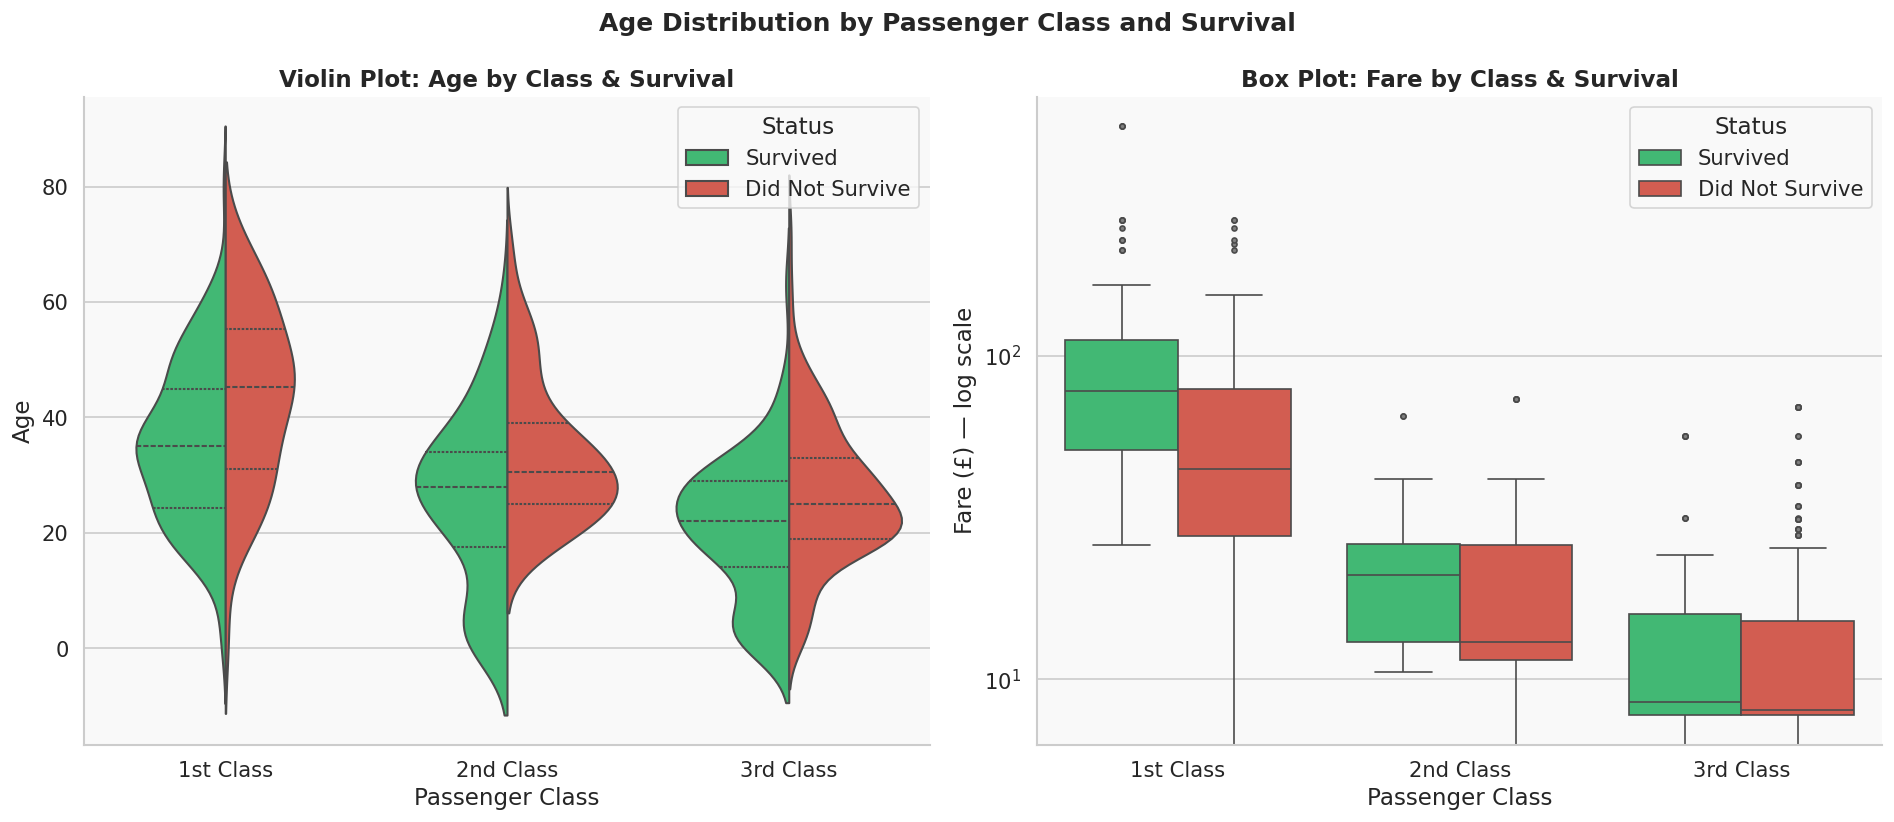

💡 Insight: 1st class passengers were older on average. Within every class, survivors generally paid higher fares than non-survivors.


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
#  FIGURE 5 ─ Violin + Box Plot: Age by Class & Survival
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Age Distribution by Passenger Class and Survival',
             fontsize=15, fontweight='bold')

# ── Violin Plot ───────────────────────────────────────────────────────────────
ax = axes[0]
sns.violinplot(data=df, x='PClass', y='Age', hue='Survived_Label',
               palette={'Survived': '#2ECC71', 'Did Not Survive': '#E74C3C'},
               split=True, inner='quartile', ax=ax)
ax.set_title('Violin Plot: Age by Class & Survival', fontweight='bold')
ax.set_xlabel('Passenger Class')
ax.set_ylabel('Age')
ax.set_xticklabels(['1st Class', '2nd Class', '3rd Class'])
ax.legend(title='Status', loc='upper right')

# ── Box Plot ──────────────────────────────────────────────────────────────────
ax = axes[1]
sns.boxplot(data=df, x='PClass', y='Fare', hue='Survived_Label',
            palette={'Survived': '#2ECC71', 'Did Not Survive': '#E74C3C'},
            flierprops={'markerfacecolor': 'gray', 'markersize': 3},
            ax=ax)
ax.set_title('Box Plot: Fare by Class & Survival', fontweight='bold')
ax.set_xlabel('Passenger Class')
ax.set_ylabel('Fare (£)')
ax.set_xticklabels(['1st Class', '2nd Class', '3rd Class'])
ax.legend(title='Status', loc='upper right')
ax.set_yscale('log')
ax.set_ylabel('Fare (£) — log scale')

plt.tight_layout()
plt.savefig('fig5_violin_box.png', bbox_inches='tight', dpi=150)
plt.show()
print('💡 Insight: 1st class passengers were older on average.',
      'Within every class, survivors generally paid higher fares than non-survivors.')

## 5. 🌐 Multivariate Analysis
Exploring interactions among multiple variables simultaneously.

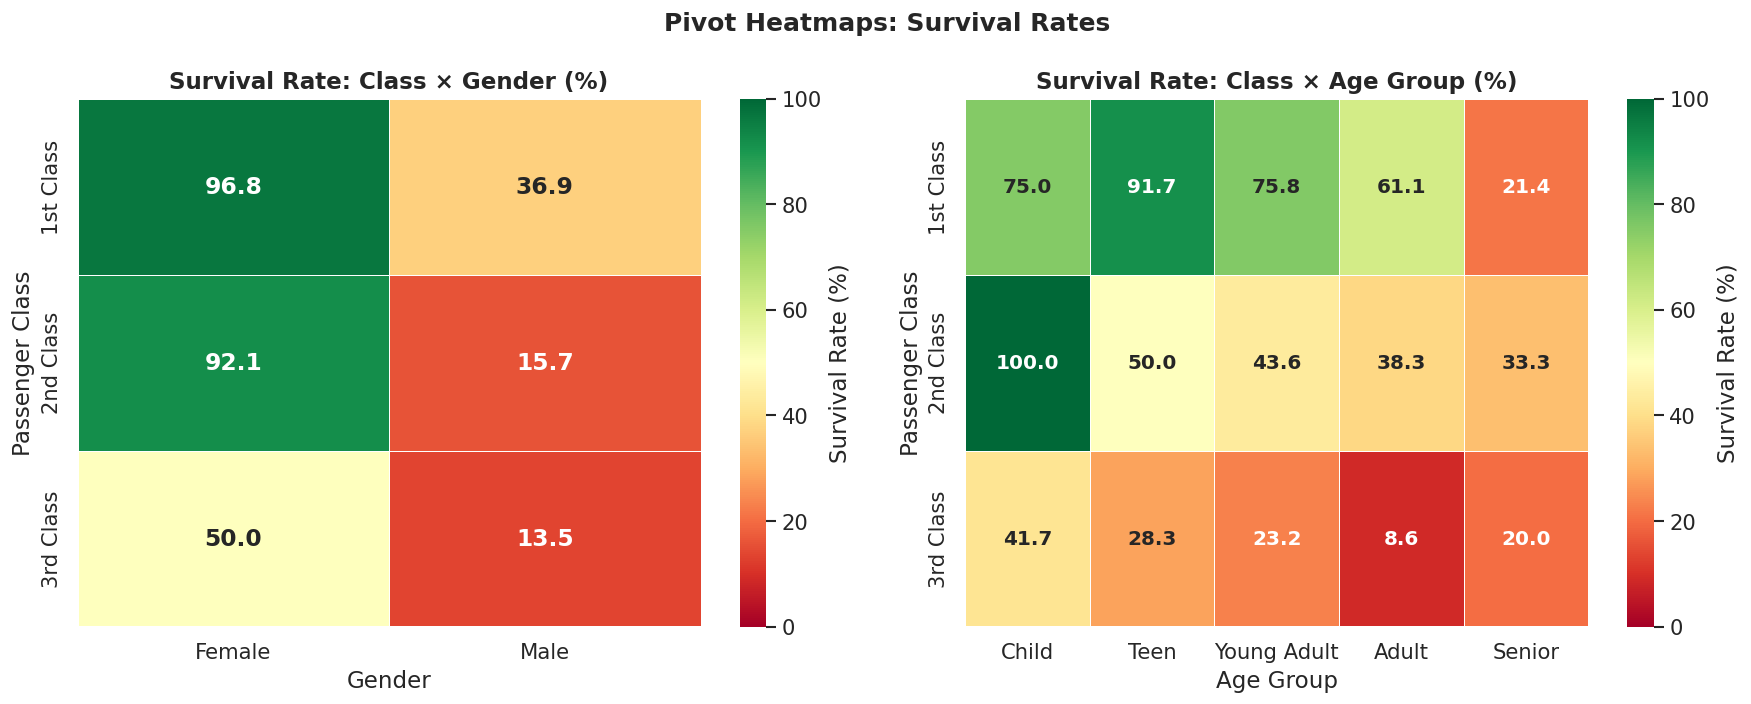

💡 Insight: 1st-class females had a near-perfect survival rate (~97%). 3rd-class males had the lowest (~15%). Children in 1st and 2nd class all survived.


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
#  FIGURE 6 ─ Survival Heatmap: Class × Gender
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Pivot Heatmaps: Survival Rates', fontsize=15, fontweight='bold')

# ── Class × Gender ─────────────────────────────────────────────────────────
ax = axes[0]
pivot1 = df.pivot_table(values='Survived', index='PClass',
                        columns='Sex', aggfunc='mean') * 100
pivot1.index = ['1st Class', '2nd Class', '3rd Class']
pivot1.columns = ['Female', 'Male']
sns.heatmap(pivot1, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.5, linecolor='white',
            vmin=0, vmax=100, ax=ax,
            annot_kws={'size': 14, 'weight': 'bold'},
            cbar_kws={'label': 'Survival Rate (%)'})
ax.set_title('Survival Rate: Class × Gender (%)', fontweight='bold')
ax.set_xlabel('Gender')
ax.set_ylabel('Passenger Class')

# ── Class × Age Group ──────────────────────────────────────────────────────
ax = axes[1]
pivot2 = df.dropna(subset=['AgeGroup']).pivot_table(
    values='Survived', index='PClass',
    columns='AgeGroup', aggfunc='mean') * 100
pivot2.index = ['1st Class', '2nd Class', '3rd Class']
pivot2 = pivot2[['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']]
sns.heatmap(pivot2, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.5, linecolor='white',
            vmin=0, vmax=100, ax=ax,
            annot_kws={'size': 12, 'weight': 'bold'},
            cbar_kws={'label': 'Survival Rate (%)'})
ax.set_title('Survival Rate: Class × Age Group (%)', fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('Passenger Class')

plt.tight_layout()
plt.savefig('fig6_survival_heatmaps.png', bbox_inches='tight', dpi=150)
plt.show()
print('💡 Insight: 1st-class females had a near-perfect survival rate (~97%).',
      '3rd-class males had the lowest (~15%). Children in 1st and 2nd class all survived.')

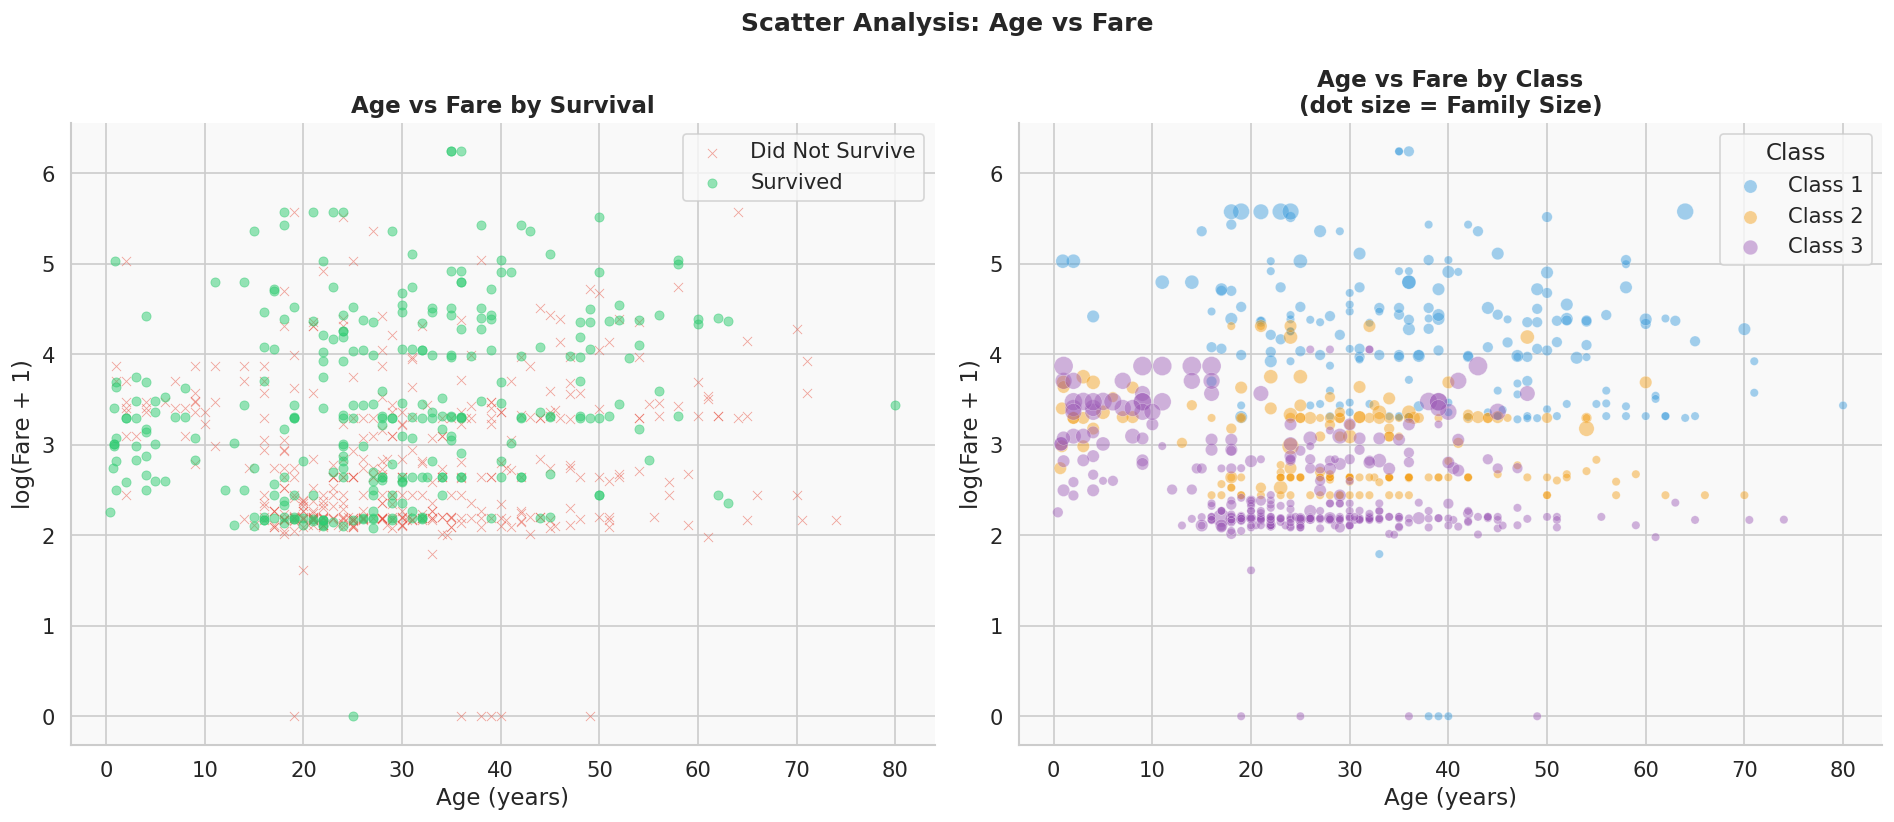

💡 Insight: Higher-fare passengers (1st class) appear more often in the survived group. Young children with low fares in 3rd class show mixed survival outcomes.


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
#  FIGURE 7 ─ Scatter Plot: Age vs Fare coloured by Survival + Class
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Scatter Analysis: Age vs Fare', fontsize=15, fontweight='bold')

# ── Coloured by Survival ──────────────────────────────────────────────────────
ax = axes[0]
for surv, color, label, marker in [(0, '#E74C3C', 'Did Not Survive', 'x'),
                                    (1, '#2ECC71', 'Survived', 'o')]:
    sub = df[df['Survived'] == surv].dropna(subset=['Age', 'Fare'])
    ax.scatter(sub['Age'], np.log1p(sub['Fare']), c=color, alpha=0.5,
               marker=marker, s=30, label=label, linewidths=0.5)
ax.set_xlabel('Age (years)')
ax.set_ylabel('log(Fare + 1)')
ax.set_title('Age vs Fare by Survival', fontweight='bold')
ax.legend()

# ── Coloured by Class (sized by FamilySize) ───────────────────────────────────
ax = axes[1]
class_colors = {1: '#3498DB', 2: '#F39C12', 3: '#9B59B6'}
for cls, color in class_colors.items():
    sub = df[df['PClass'] == cls].dropna(subset=['Age', 'Fare'])
    ax.scatter(sub['Age'], np.log1p(sub['Fare']), c=color, alpha=0.45,
               s=sub['FamilySize'] * 15 + 10, label=f'Class {cls}', edgecolors='white',
               linewidths=0.3)
ax.set_xlabel('Age (years)')
ax.set_ylabel('log(Fare + 1)')
ax.set_title('Age vs Fare by Class\n(dot size = Family Size)', fontweight='bold')
ax.legend(title='Class')

plt.tight_layout()
plt.savefig('fig7_scatter_age_fare.png', bbox_inches='tight', dpi=150)
plt.show()
print('💡 Insight: Higher-fare passengers (1st class) appear more often in the survived group.',
      'Young children with low fares in 3rd class show mixed survival outcomes.')

## 6. 🔥 Correlation Heatmap

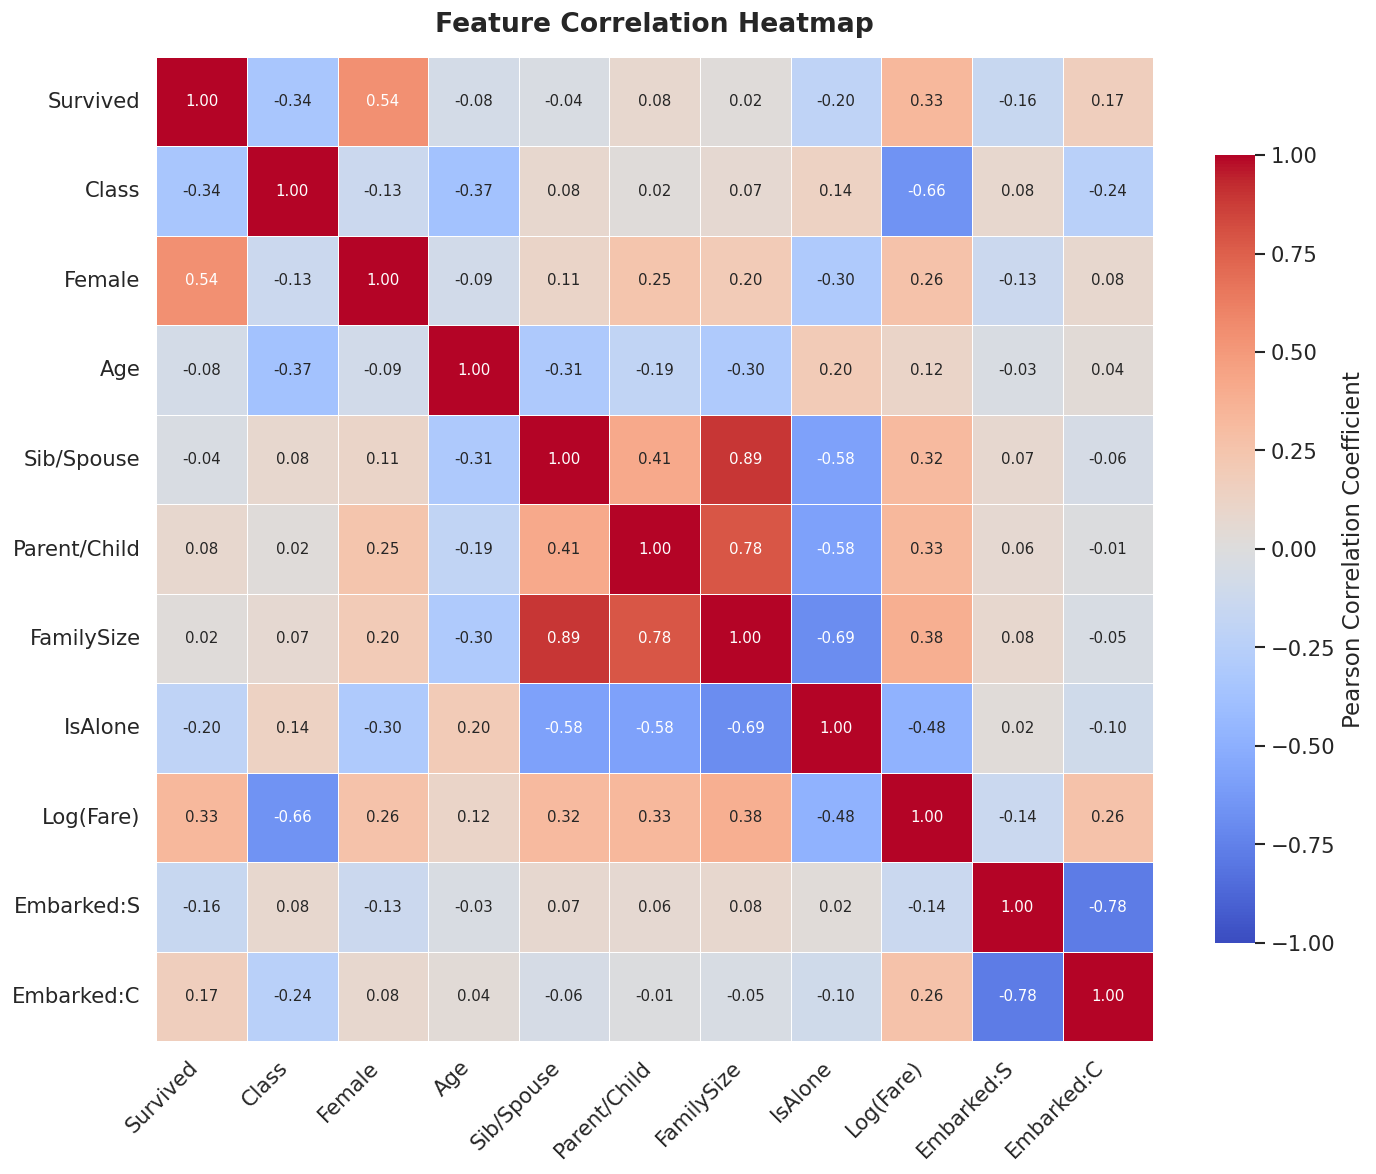

💡 Insight: "Female" has the strongest positive correlation with survival (+0.54). "Class" has a strong negative correlation (−0.34, lower class → lower survival). "Log(Fare)" is positively correlated (+0.26), confirming wealthier passengers survived more.


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
#  FIGURE 8 ─ Correlation Heatmap
# ─────────────────────────────────────────────────────────────────────────────
# Encode categoricals
df_corr = df.copy()
df_corr['Sex_Enc']      = (df_corr['Sex'] == 'female').astype(int)
df_corr['Embarked_S']   = (df_corr['Embarked'] == 'S').astype(int)
df_corr['Embarked_C']   = (df_corr['Embarked'] == 'C').astype(int)
df_corr['LogFare']      = np.log1p(df_corr['Fare'])

corr_cols = ['Survived', 'PClass', 'Sex_Enc', 'Age', 'SiblingSpouse',
             'ParentChild', 'FamilySize', 'IsAlone', 'LogFare',
             'Embarked_S', 'Embarked_C']
corr_labels = ['Survived', 'Class', 'Female', 'Age', 'Sib/Spouse',
               'Parent/Child', 'FamilySize', 'IsAlone', 'Log(Fare)',
               'Embarked:S', 'Embarked:C']

corr_matrix = df_corr[corr_cols].rename(columns=dict(zip(corr_cols, corr_labels))).corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 9}, ax=ax,
            cbar_kws={'label': 'Pearson Correlation Coefficient', 'shrink': 0.8})
ax.set_title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('fig8_correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print('💡 Insight: "Female" has the strongest positive correlation with survival (+0.54).',
      '"Class" has a strong negative correlation (−0.34, lower class → lower survival).',
      '"Log(Fare)" is positively correlated (+0.26), confirming wealthier passengers survived more.')

## 7. 🎨 Advanced Visualizations

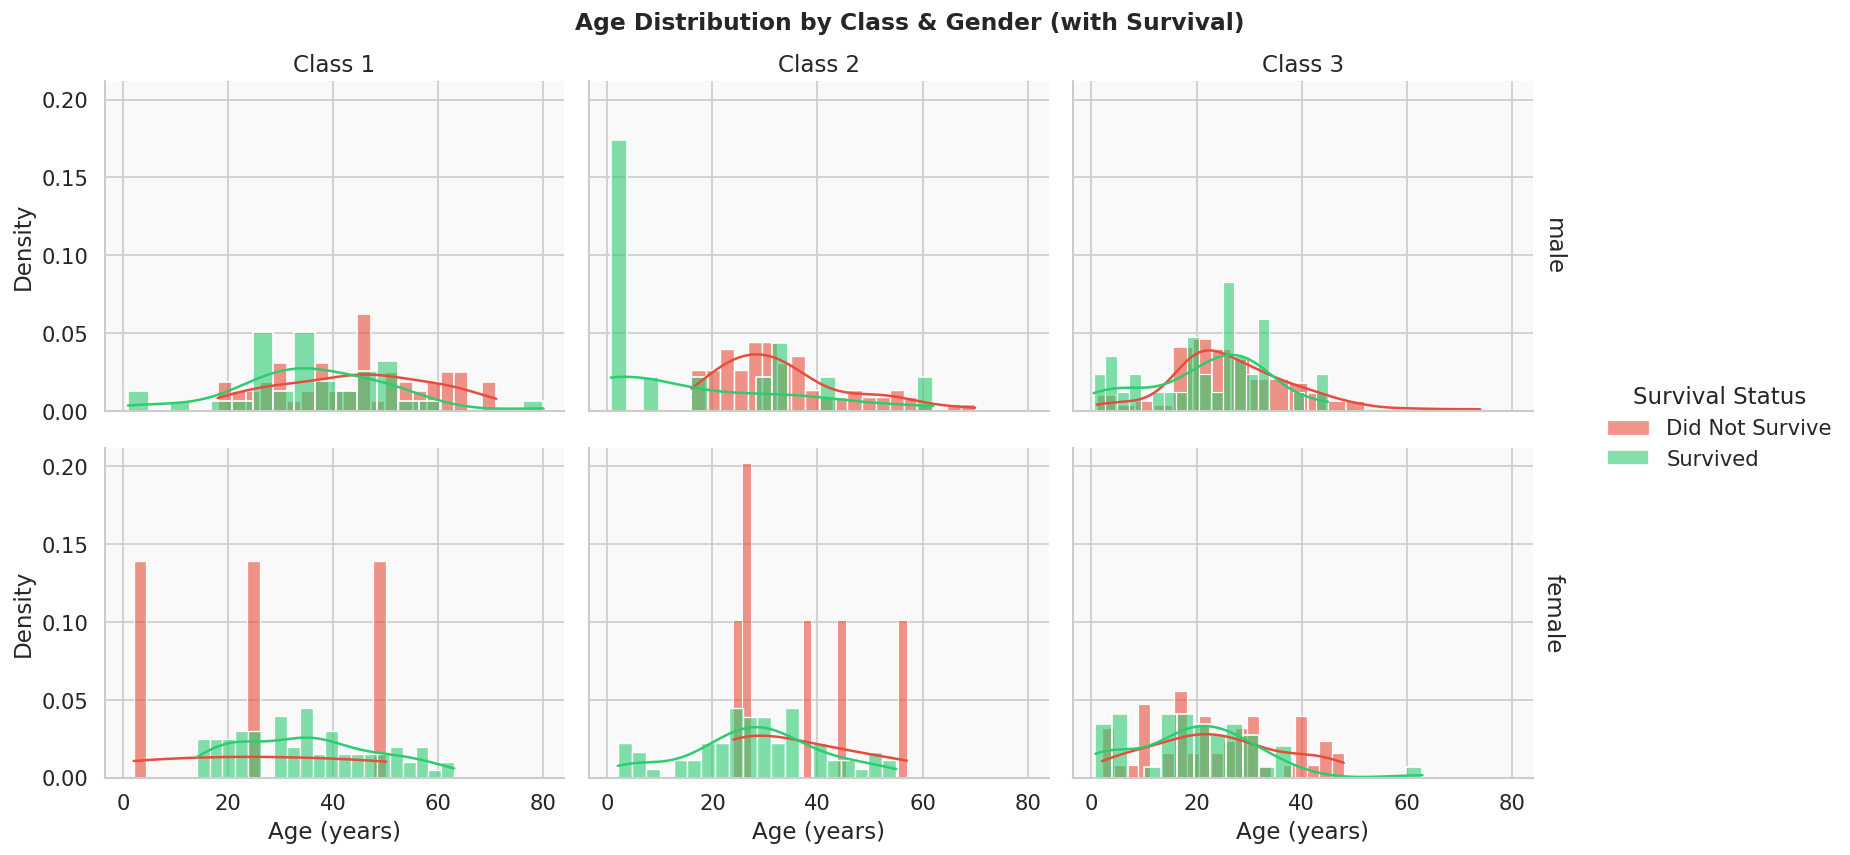

💡 Insight: FacetGrid shows the joint effect of class, gender, and age. Female 1st/2nd-class passengers show very high survival across all ages.


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
#  FIGURE 9 ─ FacetGrid: Age Distribution by Class & Gender
# ─────────────────────────────────────────────────────────────────────────────
g = sns.FacetGrid(
    data=df.dropna(subset=['Age']),
    col='PClass', row='Sex',
    hue='Survived_Label',
    palette={'Survived': '#2ECC71', 'Did Not Survive': '#E74C3C'},
    height=3.5, aspect=1.3,
    margin_titles=True
)
g.map(sns.histplot, 'Age', bins=20, alpha=0.6, kde=True, stat='density')
g.set_axis_labels('Age (years)', 'Density')
g.set_titles(col_template='Class {col_name}', row_template='{row_name}')
g.add_legend(title='Survival Status')
g.figure.suptitle('Age Distribution by Class & Gender (with Survival)',
                   y=1.02, fontsize=14, fontweight='bold')
g.figure.savefig('fig9_facetgrid.png', bbox_inches='tight', dpi=150)
plt.show()
print('💡 Insight: FacetGrid shows the joint effect of class, gender, and age.',
      'Female 1st/2nd-class passengers show very high survival across all ages.')

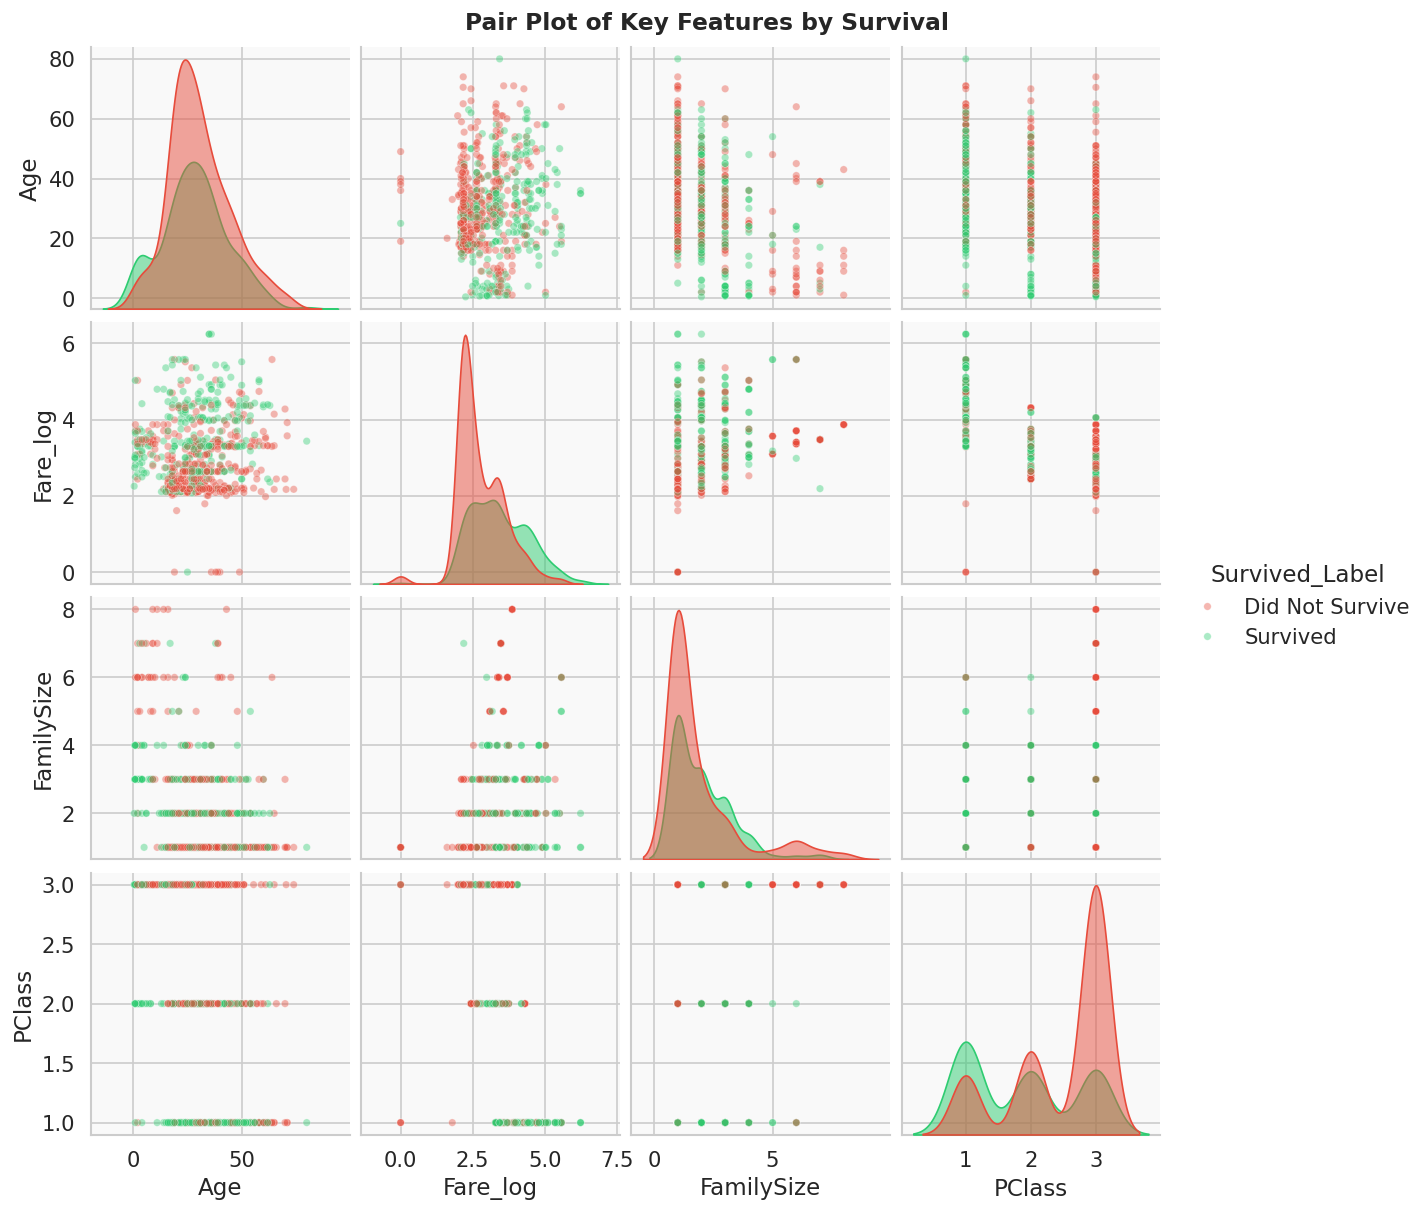

💡 Insight: The pair plot confirms that log(Fare) vs PClass most strongly separates survivors from non-survivors. FamilySize shows mild interaction with survival.


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
#  FIGURE 10 ─ Pair Plot: Key Numeric Features
# ─────────────────────────────────────────────────────────────────────────────
pair_df = df[['Age', 'Fare', 'FamilySize', 'PClass', 'Survived_Label']].dropna()
pair_df['Fare_log'] = np.log1p(pair_df['Fare'])

g = sns.pairplot(
    pair_df[['Age', 'Fare_log', 'FamilySize', 'PClass', 'Survived_Label']],
    hue='Survived_Label',
    palette={'Survived': '#2ECC71', 'Did Not Survive': '#E74C3C'},
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 20},
    diag_kws={'fill': True, 'alpha': 0.5}
)
g.figure.suptitle('Pair Plot of Key Features by Survival',
                   y=1.01, fontsize=14, fontweight='bold')
g.figure.savefig('fig10_pairplot.png', bbox_inches='tight', dpi=150)
plt.show()
print('💡 Insight: The pair plot confirms that log(Fare) vs PClass most strongly separates',
      'survivors from non-survivors. FamilySize shows mild interaction with survival.')

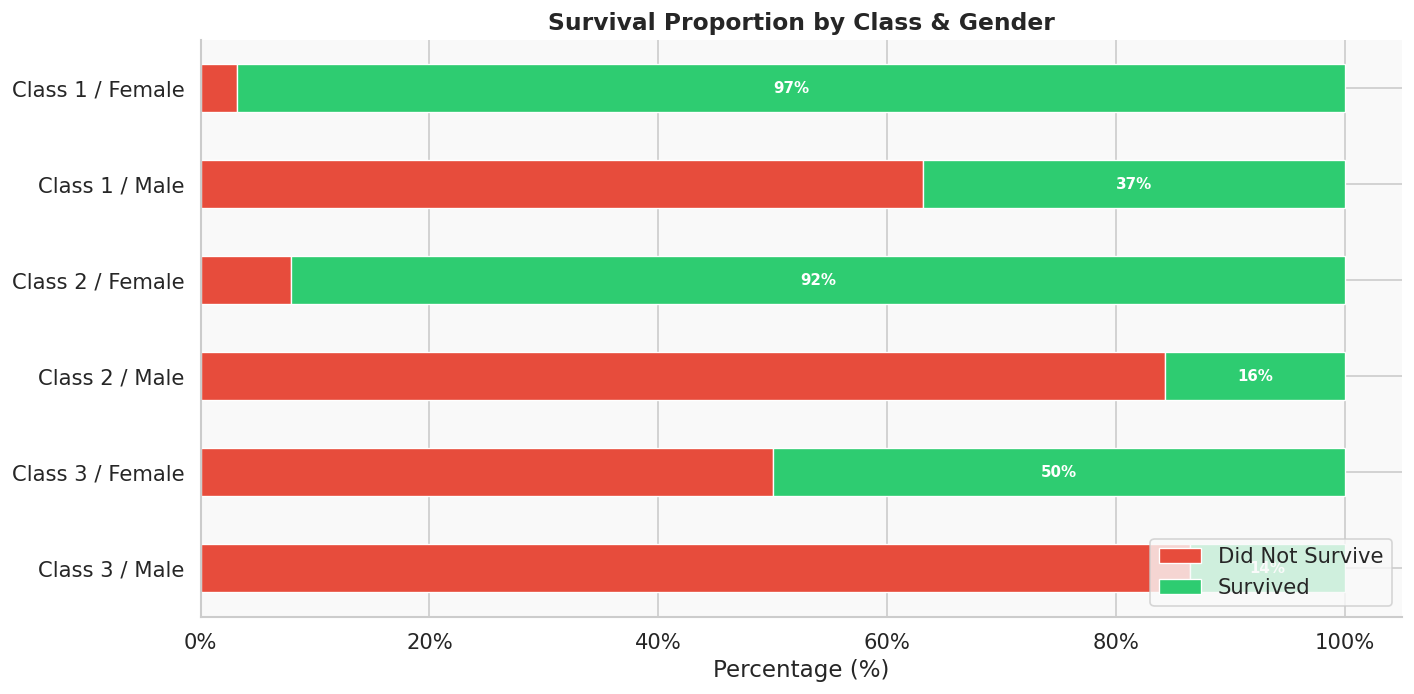

💡 Insight: 1st-class females had the highest survival (~97%), while 3rd-class males had the lowest (~15%), vividly showing intersectional disparities.


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
#  FIGURE 11 ─ Stacked Bar: Survival Proportion by Class & Gender
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

cross = pd.crosstab(
    [df['PClass'], df['Sex']],
    df['Survived'],
    normalize='index'
) * 100
cross.columns = ['Did Not Survive', 'Survived']
cross.index = [f'Class {c} / {g.capitalize()}' for c, g in cross.index]

cross[['Did Not Survive', 'Survived']].plot(
    kind='barh', stacked=True, ax=ax,
    color=['#E74C3C', '#2ECC71'], edgecolor='white', linewidth=0.8
)

# Annotate survival rates
for i, (idx, row) in enumerate(cross.iterrows()):
    ax.text(row['Survived'] / 2 + row['Did Not Survive'],
            i, f"{row['Survived']:.0f}%",
            ha='center', va='center', fontweight='bold', fontsize=9, color='white')

ax.set_xlabel('Percentage (%)')
ax.set_title('Survival Proportion by Class & Gender', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(loc='lower right', frameon=True)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('fig11_stacked_bar.png', bbox_inches='tight', dpi=150)
plt.show()
print('💡 Insight: 1st-class females had the highest survival (~97%), while 3rd-class males',
      'had the lowest (~15%), vividly showing intersectional disparities.')

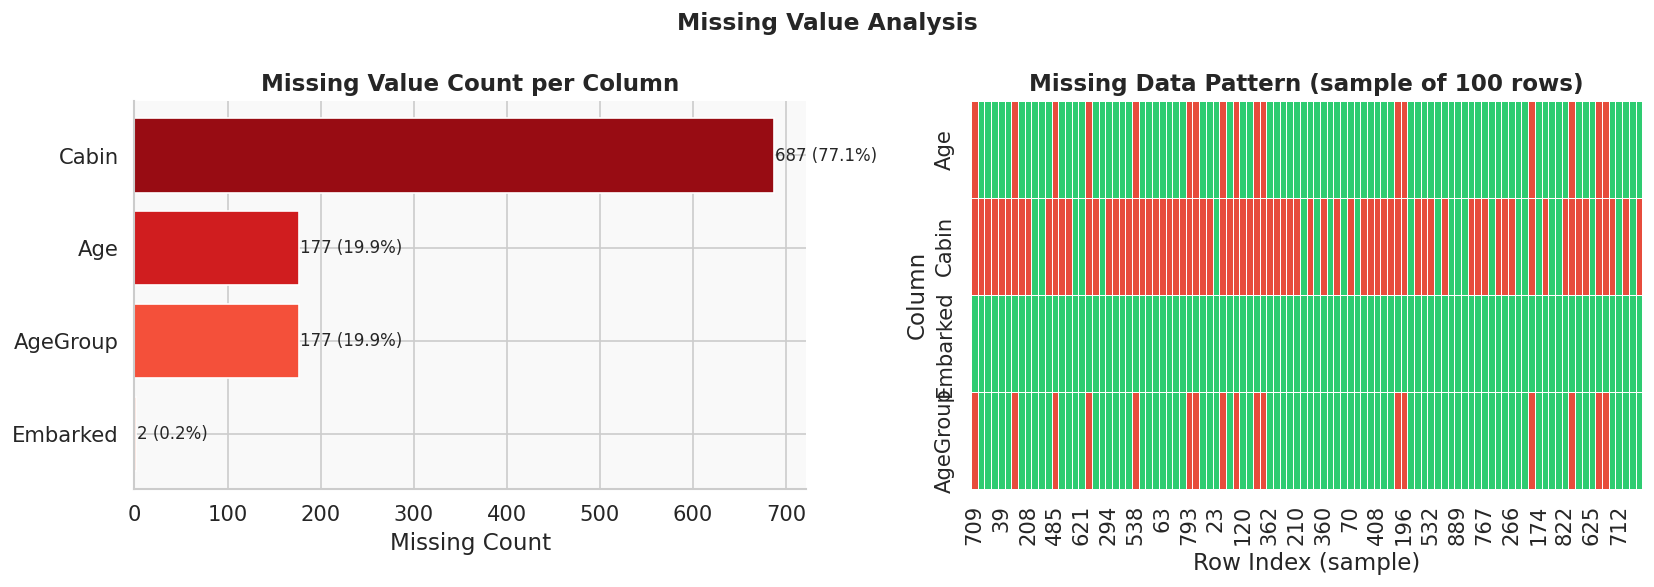

💡 Insight: "Cabin" has ~77% missing values — too many to impute reliably. "Age" has ~20% missing (median/model imputation recommended). Only 2 rows miss Embarked data.


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
#  FIGURE 12 ─ Missing Value Analysis
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Missing Value Analysis', fontsize=14, fontweight='bold')

# ── Bar Chart of Missing Values ───────────────────────────────────────────────
ax = axes[0]
miss = df.isnull().sum().sort_values(ascending=False)
miss = miss[miss > 0]
colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(miss)))
bars = ax.barh(miss.index, miss.values, color=colors[::-1], edgecolor='white')
for bar, val in zip(bars, miss.values):
    pct = val / len(df) * 100
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{val} ({pct:.1f}%)', va='center', fontsize=10)
ax.set_title('Missing Value Count per Column', fontweight='bold')
ax.set_xlabel('Missing Count')
ax.invert_yaxis()

# ── Heatmap of Missing Patterns ───────────────────────────────────────────────
ax = axes[1]
miss_cols = df.isnull().any()
miss_cols = miss_cols[miss_cols].index.tolist()
sample = df[miss_cols].isnull().sample(min(100, len(df)), random_state=42)
sns.heatmap(sample.T, cmap=['#2ECC71', '#E74C3C'], cbar=False,
            linewidths=0.3, linecolor='white', ax=ax, yticklabels=miss_cols)
ax.set_title('Missing Data Pattern (sample of 100 rows)', fontweight='bold')
ax.set_xlabel('Row Index (sample)')
ax.set_ylabel('Column')

plt.tight_layout()
plt.savefig('fig12_missing_values.png', bbox_inches='tight', dpi=150)
plt.show()
print('💡 Insight: "Cabin" has ~77% missing values — too many to impute reliably.',
      '"Age" has ~20% missing (median/model imputation recommended).',
      'Only 2 rows miss Embarked data.')

## 8. 📝 Summary of Key Insights

| # | Insight | Visualization Used |
|---|---------|--------------------|
| 1 | Only **38%** of passengers survived — a highly imbalanced target | Bar Chart (Fig 2) |
| 2 | **Gender** is the strongest survival predictor: women ~74% vs men ~19% | Bar Plot (Fig 3) |
| 3 | **1st-class passengers** had ~63% survival vs only ~24% for 3rd class | Grouped Bar (Fig 3) |
| 4 | **Children** had the highest survival rate across all age groups | Age Group Bar (Fig 3) |
| 5 | **Higher fare** correlates strongly with survival (wealthier = safer) | Distribution (Fig 4) |
| 6 | **1st-class females** nearly all survived (~97%); **3rd-class males** barely (~15%) | Heatmap (Fig 6) |
| 7 | **Female gender** shows the strongest positive correlation (+0.54) with survival | Heatmap (Fig 8) |
| 8 | **Cabin** column has ~77% missing data — likely dropped in modeling | Missing Analysis (Fig 12) |

---
### Conclusion
The Titanic dataset reveals stark social inequalities in survival. The "women and children first" protocol, combined with socioeconomic class, were the dominant factors. These visualizations provide a strong foundation for building a predictive survival model.